# RL Environment Design
Objective: Build a Gym-compatible reinforcement learning environment for training the LLM recommendation agent.
Outputs:

artifacts/env/env_config.json
artifacts/env/env_test_results.json

## 1. Setup & Load All Features

In [ ]:
# Setup & Load All Features
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Use local project root for imports
BASE_DIR = Path.cwd()
if not (BASE_DIR / "utils.py").exists():
    BASE_DIR = BASE_DIR.parent
sys.path.insert(0, str(BASE_DIR))

from utils import PathManager, save_json
from rl_env import LLMRecommendationEnv, RewardWeights

# Initialize paths
paths = PathManager(BASE_DIR)

# Load features with scores from Sprint 4
features_file = paths.PROCESSED_DIR / "features_with_scores.parquet"
df_features = pd.read_parquet(features_file)

# Load embeddings from Sprint 3
embeddings_file = paths.INDEXES_DIR / "model_embeddings.npy"
embeddings = np.load(embeddings_file)

print(f"✅ Loaded data")
print(f"   Features shape: {df_features.shape}")
print(f"   Embeddings shape: {embeddings.shape}")
print(f"\nAvailable feature columns:")
feature_cols = [col for col in df_features.columns if col.endswith('_score')]
for col in feature_cols:
    non_null = df_features[col].notna().sum()
    print(f"  {col:25s}: {non_null}/{len(df_features)} ({non_null/len(df_features)*100:.1f}%)")



✅ Loaded data
   Features shape: (95, 35)
   Embeddings shape: (95, 384)

Available feature columns:
  cost_score               : 86/95 (90.5%)
  popularity_score         : 95/95 (100.0%)
  recency_score            : 95/95 (100.0%)
  diversity_score          : 95/95 (100.0%)
  average_score            : 46/95 (48.4%)
  composite_score          : 46/95 (48.4%)
  performance_score        : 46/95 (48.4%)


## 2. Initialize RL Environment
Create the Gym environment with all features and embeddings.

In [10]:
# Initialize RL Environment
print("="*60)
print("INITIALIZING RL ENVIRONMENT")
print("="*60)

# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    print("Installing gymnasium...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium"])
    import gymnasium as gym

# Define reward weights
reward_weights = RewardWeights(
    performance=0.4,   # Prioritize quality
    cost=0.2,          # Penalize expensive models
    diversity=0.2,     # Encourage variety
    popularity=0.1,    # Consider trends
    recency=0.1        # Slight preference for newer
)

print(f"\nReward Weights:")
print(f"  Performance: {reward_weights.performance}")
print(f"  Cost:        {reward_weights.cost}")
print(f"  Diversity:   {reward_weights.diversity}")
print(f"  Popularity:  {reward_weights.popularity}")
print(f"  Recency:     {reward_weights.recency}")
print(f"  Total:       {sum([reward_weights.performance, reward_weights.cost, reward_weights.diversity, reward_weights.popularity, reward_weights.recency])}")

# Create environment
env = LLMRecommendationEnv(
    features_df=df_features,
    embeddings=embeddings,
    reward_weights=reward_weights,
    top_k=5,
    max_steps_per_episode=10
)

print(f"\n✅ Environment created")
print(f"   Action space: {env.action_space}")
print(f"   Observation space: {env.observation_space}")
print(f"   Number of models: {env.n_models}")
print(f"   Top-K recommendations: {env.top_k}")
print(f"   Max steps per episode: {env.max_steps}")



INITIALIZING RL ENVIRONMENT

Reward Weights:
  Performance: 0.4
  Cost:        0.2
  Diversity:   0.2
  Popularity:  0.1
  Recency:     0.1
  Total:       1.0

✅ Environment created
   Action space: Box(0.0, 1.0, (95,), float32)
   Observation space: Box(-inf, inf, (6,), float32)
   Number of models: 95
   Top-K recommendations: 5
   Max steps per episode: 10


## 3. Test Environment Initialization
Verify the environment is properly configured.

In [11]:
# Test Environment Initialization
print("="*60)
print("TESTING ENVIRONMENT INITIALIZATION")
print("="*60)

# Reset environment
obs, info = env.reset(seed=42)

print(f"✅ Environment reset successful")
print(f"\nInitial Observation:")
print(f"  Shape: {obs.shape}")
print(f"  Values: {obs}")
print(f"\nInitial Info:")
for key, value in info.items():
    print(f"  {key}: {value}")

# Verify observation space
assert env.observation_space.contains(obs), "Observation not in observation space!"
print(f"\n✅ Observation space validated")


TESTING ENVIRONMENT INITIALIZATION
✅ Environment reset successful

Initial Observation:
  Shape: (6,)
  Values: [0.09614353 0.5181852  0.5        0.67440194 0.43132547 0.        ]

Initial Info:
  step: 0
  models_recommended: 0
  episode_return: 0
  mean_episode_reward: 0.0

✅ Observation space validated


## 4. Test Reward Function Components
Analyze individual reward components.

TESTING REWARD FUNCTION
✅ Step executed

Reward: 0.4728
Terminated: False
Truncated: False

Reward Components:
  performance : 0.1779 (weight: 0.40, contribution: 0.0711)
  cost        : 0.8695 (weight: 0.20, contribution: 0.1739)
  diversity   : 0.6864 (weight: 0.20, contribution: 0.1373)
  popularity  : 0.4052 (weight: 0.10, contribution: 0.0405)
  recency     : 0.5000 (weight: 0.10, contribution: 0.0500)

Selected Models:


,model_id,cost_score,popularity_score,recency_score,diversity_score,performance_score
76,LiquidAI/LFM2-1.2B,0.003208,0.401728,0.5,0.500000,NaN
26,context-labs/meta-llama-Llama-3.2-3B-Instruct-...,0.008575,0.361030,0.5,0.738636,NaN
42,Qwen/Qwen3-Coder-30B-A3B-Instruct,0.089082,0.571060,0.5,0.522727,NaN
44,kaitchup/Phi-3-mini-4k-instruct-gptq-4bit,NaN,0.186018,0.5,0.931818,NaN
58,meta-llama/Llama-3.1-70B-Instruct,0.051811,0.506247,0.5,0.738636,0.889345


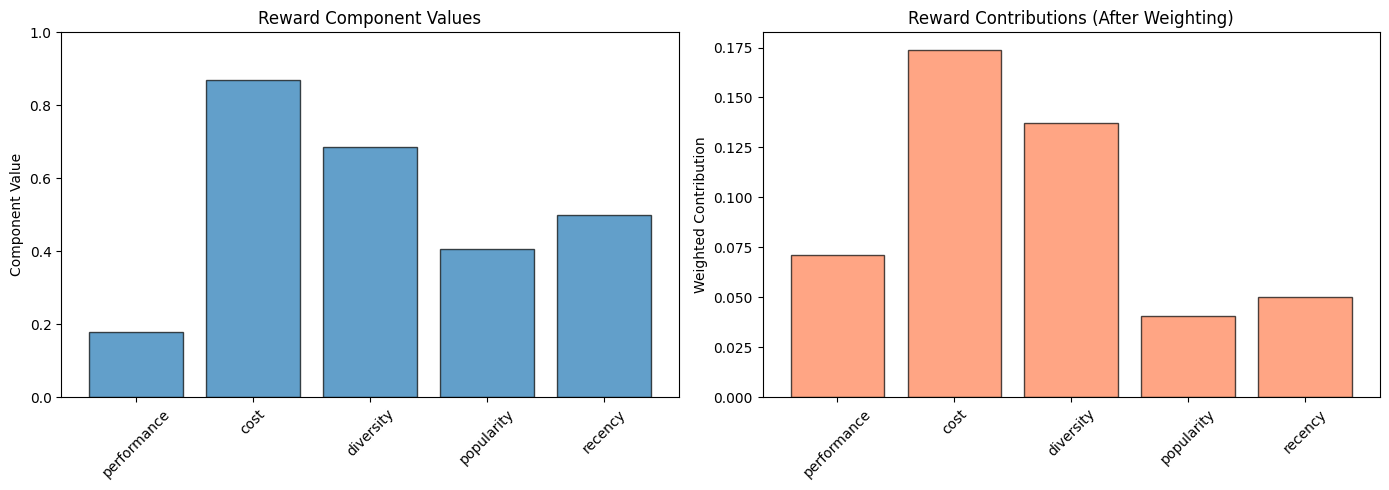

In [12]:
# Test Reward Function Components
print("="*60)
print("TESTING REWARD FUNCTION")
print("="*60)

# Take a random action
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

print(f"✅ Step executed")
print(f"\nReward: {reward:.4f}")
print(f"Terminated: {terminated}")
print(f"Truncated: {truncated}")

print(f"\nReward Components:")
components = info['reward_components']
for component, value in components.items():
    weight = getattr(reward_weights, component)
    contribution = weight * value
    print(f"  {component:12s}: {value:.4f} (weight: {weight:.2f}, contribution: {contribution:.4f})")

print(f"\nSelected Models:")
selected = info['selected_models']
model_info = env.get_model_info(selected)
display(model_info)

# Visualize reward components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Component values
comp_names = list(components.keys())
comp_values = list(components.values())

axes[0].bar(comp_names, comp_values, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Component Value')
axes[0].set_title('Reward Component Values')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)

# Weighted contributions
contributions = [getattr(reward_weights, name) * value
                for name, value in components.items()]

axes[1].bar(comp_names, contributions, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_ylabel('Weighted Contribution')
axes[1].set_title('Reward Contributions (After Weighting)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Analysis of NAN values

In [13]:
# Analyze NaN Impact on Rewards

print("="*60)
print("NaN IMPACT ANALYSIS")
print("="*60)

# Check NaN coverage across all models
feature_cols = ['cost_score', 'popularity_score', 'recency_score',
                'diversity_score', 'performance_score']

print("\nFeature Completeness Across All Models:")
for col in feature_cols:
    non_null = df_features[col].notna().sum()
    pct = (non_null / len(df_features)) * 100
    print(f"  {col:25s}: {non_null:3d}/{len(df_features)} ({pct:5.1f}%)")

# Simulate reward with different NaN handling strategies
print(f"\n{'='*60}")
print("REWARD COMPARISON: fillna(0.0) vs valid-only averaging")
print(f"{'='*60}")

# Take a random sample of models
np.random.seed(42)
sample_indices = np.random.choice(len(df_features), size=5, replace=False)

sample_features = df_features.iloc[sample_indices]

print("\nSample Models:")
display(sample_features[['model_id'] + feature_cols])

# OLD method: fillna(0.0)
perf_old = sample_features['performance_score'].fillna(0.0).mean()

# NEW method: valid-only
perf_scores = sample_features['performance_score'].values
valid_perf = perf_scores[~np.isnan(perf_scores)]
perf_new = valid_perf.mean() if len(valid_perf) > 0 else 0.5

print(f"\nPerformance Score Comparison:")
print(f"  OLD (fillna=0.0):        {perf_old:.4f}")
print(f"  NEW (valid-only):        {perf_new:.4f}")
print(f"  Difference:              {perf_new - perf_old:+.4f}")
print(f"  Valid scores in sample:  {len(valid_perf)}/5")

# Impact on total reward
reward_old = 0.4 * perf_old + 0.6 * 0.7  # Simplified
reward_new = 0.4 * perf_new + 0.6 * 0.7

print(f"\nReward Impact (simplified):")
print(f"  OLD total reward: {reward_old:.4f}")
print(f"  NEW total reward: {reward_new:.4f}")
print(f"  Change:           {reward_new - reward_old:+.4f} ({(reward_new/reward_old - 1)*100:+.1f}%)")

NaN IMPACT ANALYSIS

Feature Completeness Across All Models:
  cost_score               :  86/95 ( 90.5%)
  popularity_score         :  95/95 (100.0%)
  recency_score            :  95/95 (100.0%)
  diversity_score          :  95/95 (100.0%)
  performance_score        :  46/95 ( 48.4%)

REWARD COMPARISON: fillna(0.0) vs valid-only averaging

Sample Models:


,model_id,cost_score,popularity_score,recency_score,diversity_score,performance_score
68,Qwen/Qwen3-30B-A3B-GPTQ-Int4,0.026466,0.274929,0.5,0.522727,NaN
22,deepseek-ai/DeepSeek-R1-Distill-Qwen-32B,0.095046,0.720884,0.5,0.522727,0.403807
72,meta-llama/Llama-2-7b-hf,0.020502,0.531323,0.5,0.738636,0.130449
73,Qwen/Qwen2-1.5B-Instruct,0.004103,0.353808,0.5,0.522727,0.241199
0,openai-community/gpt2,0.014539,1.000000,0.5,0.909091,0.078348



Performance Score Comparison:
  OLD (fillna=0.0):        0.1708
  NEW (valid-only):        0.2135
  Difference:              +0.0427
  Valid scores in sample:  4/5

Reward Impact (simplified):
  OLD total reward: 0.4883
  NEW total reward: 0.5054
  Change:           +0.0171 (+3.5%)


## 5. Test Episode Simulation
Run a complete episode to validate the environment.


SIMULATING FULL EPISODE
Running episode with max 10 steps...

Step 1: Reward=0.5338, Models recommended=5
Step 2: Reward=0.4160, Models recommended=10
Step 3: Reward=0.5257, Models recommended=15
Step 4: Reward=0.4732, Models recommended=20
Step 5: Reward=0.5294, Models recommended=25
Step 6: Reward=0.5344, Models recommended=30
Step 7: Reward=0.4604, Models recommended=35
Step 8: Reward=0.5365, Models recommended=40
Step 9: Reward=0.3919, Models recommended=45
Step 10: Reward=0.4221, Models recommended=50

Episode ended: Truncated

✅ Episode complete
   Total steps: 10
   Episode return: 4.8234
   Mean reward: 0.4823
   Std reward: 0.0540


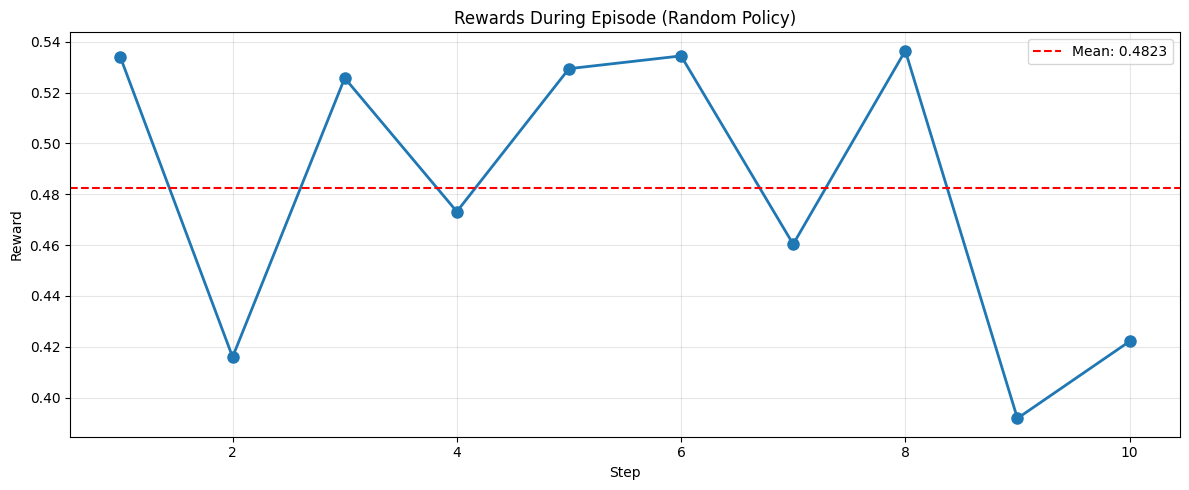

In [14]:
# Test Episode Simulation
print("="*60)
print("SIMULATING FULL EPISODE")
print("="*60)

# Reset environment
obs, info = env.reset(seed=123)

episode_rewards = []
episode_info = []

print(f"Running episode with max {env.max_steps} steps...\n")

for step in range(env.max_steps):
    # Random policy (for testing)
    action = env.action_space.sample()

    # Execute step
    obs, reward, terminated, truncated, info = env.step(action)

    episode_rewards.append(reward)
    episode_info.append(info.copy())

    print(f"Step {step+1}: Reward={reward:.4f}, Models recommended={info['models_recommended']}")

    if terminated or truncated:
        print(f"\nEpisode ended: {'Terminated' if terminated else 'Truncated'}")
        break

print(f"\n✅ Episode complete")
print(f"   Total steps: {len(episode_rewards)}")
print(f"   Episode return: {sum(episode_rewards):.4f}")
print(f"   Mean reward: {np.mean(episode_rewards):.4f}")
print(f"   Std reward: {np.std(episode_rewards):.4f}")

# Plot episode rewards
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(episode_rewards)+1), episode_rewards,
         marker='o', linewidth=2, markersize=8)
plt.axhline(y=np.mean(episode_rewards), color='red', linestyle='--',
            label=f'Mean: {np.mean(episode_rewards):.4f}')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Rewards During Episode (Random Policy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Validate Gym Compatibility
Ensure the environment follows Gym interface standards.

In [15]:
# Validate Gym Compatibility
print("="*60)
print("VALIDATING GYM COMPATIBILITY")
print("="*60)

# Check required methods
required_methods = ['reset', 'step', 'render']
for method in required_methods:
    assert hasattr(env, method), f"Missing method: {method}"
    print(f"✅ {method}() exists")

# Check spaces
assert hasattr(env, 'action_space'), "Missing action_space"
assert hasattr(env, 'observation_space'), "Missing observation_space"
print(f"✅ action_space defined")
print(f"✅ observation_space defined")

# Verify space types
from gymnasium import spaces
assert isinstance(env.action_space, spaces.Space), "action_space not a Space"
assert isinstance(env.observation_space, spaces.Space), "observation_space not a Space"
print(f"✅ Spaces are valid Gym spaces")

# Test multiple resets
for i in range(3):
    obs, info = env.reset()
    assert env.observation_space.contains(obs), f"Reset {i+1} produced invalid observation"
print(f"✅ Multiple resets work correctly")

# Test deterministic seed
obs1, _ = env.reset(seed=42)
obs2, _ = env.reset(seed=42)
assert np.allclose(obs1, obs2), "Seeded resets not deterministic"
print(f"✅ Seeded resets are deterministic")

print(f"\n{'='*60}")
print("GYM COMPATIBILITY: PASSED ✅")
print(f"{'='*60}")

VALIDATING GYM COMPATIBILITY
✅ reset() exists
✅ step() exists
✅ render() exists
✅ action_space defined
✅ observation_space defined
✅ Spaces are valid Gym spaces
✅ Multiple resets work correctly
✅ Seeded resets are deterministic

GYM COMPATIBILITY: PASSED ✅


## 7. Environment Analysis
Visualize reward components and state space.

ENVIRONMENT ANALYSIS
Running 20 random policy episodes...

Episode 5/20: Return=4.9985, Length=10
Episode 10/20: Return=5.0319, Length=10
Episode 15/20: Return=5.0409, Length=10
Episode 20/20: Return=4.6039, Length=10

✅ Analysis complete

Random Policy Performance:
  Mean return: 4.8776 ± 0.1330
  Min return:  4.6039
  Max return:  5.0781
  Mean length: 10.00 steps


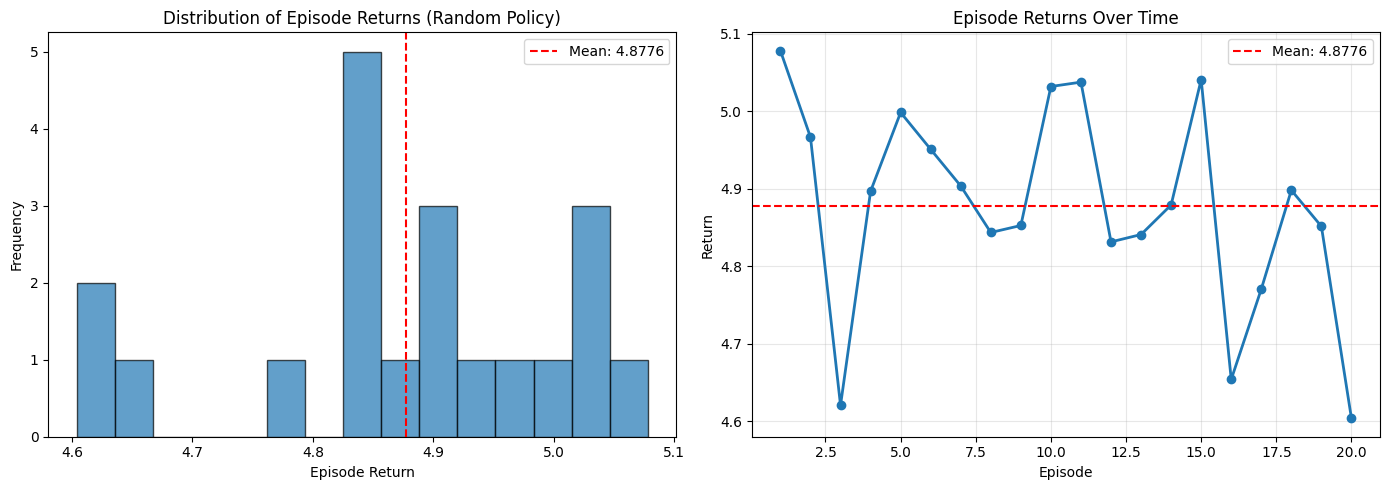

In [16]:
# Environment Analysis
print("="*60)
print("ENVIRONMENT ANALYSIS")
print("="*60)

# Run multiple episodes with random policy
n_episodes = 20
all_returns = []
all_lengths = []

print(f"Running {n_episodes} random policy episodes...\n")

for ep in range(n_episodes):
    obs, info = env.reset()
    ep_rewards = []

    for step in range(env.max_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        ep_rewards.append(reward)

        if terminated or truncated:
            break

    all_returns.append(sum(ep_rewards))
    all_lengths.append(len(ep_rewards))

    if (ep + 1) % 5 == 0:
        print(f"Episode {ep+1}/{n_episodes}: Return={sum(ep_rewards):.4f}, Length={len(ep_rewards)}")

print(f"\n✅ Analysis complete")
print(f"\nRandom Policy Performance:")
print(f"  Mean return: {np.mean(all_returns):.4f} ± {np.std(all_returns):.4f}")
print(f"  Min return:  {np.min(all_returns):.4f}")
print(f"  Max return:  {np.max(all_returns):.4f}")
print(f"  Mean length: {np.mean(all_lengths):.2f} steps")

# Visualize returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_returns, bins=15, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(all_returns), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_returns):.4f}')
axes[0].set_xlabel('Episode Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Episode Returns (Random Policy)')
axes[0].legend()

axes[1].plot(range(1, n_episodes+1), all_returns, marker='o', linewidth=2, markersize=6)
axes[1].axhline(np.mean(all_returns), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_returns):.4f}')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Return')
axes[1].set_title('Episode Returns Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Save Configuration & Export

In [17]:
# Save Configuration & Export
print("="*60)
print("SAVING CONFIGURATION")
print("="*60)

# Save environment configuration
env_config = {
    'metadata': {
        'created_at': pd.Timestamp.now().isoformat(),
        'n_models': env.n_models,
        'embedding_dim': embeddings.shape[1],
        'feature_cols': env.state_feature_cols
    },
    'hyperparameters': {
        'top_k': env.top_k,
        'max_steps_per_episode': env.max_steps,
        'action_space_dim': env.action_space.shape[0],
        'observation_space_dim': env.observation_space.shape[0]
    },
    'reward_weights': {
        'performance': reward_weights.performance,
        'cost': reward_weights.cost,
        'diversity': reward_weights.diversity,
        'popularity': reward_weights.popularity,
        'recency': reward_weights.recency
    },
    'spaces': {
        'action_space': {
            'type': 'Box',
            'shape': list(env.action_space.shape),
            'low': float(env.action_space.low[0]),
            'high': float(env.action_space.high[0])
        },
        'observation_space': {
            'type': 'Box',
            'shape': list(env.observation_space.shape),
            'low': float(env.observation_space.low.min()),
            'high': float(env.observation_space.high.max())
        }
    }
}

config_file = paths.ENV_DIR / "env_config.json"
save_json(env_config, config_file)
print(f"✅ Environment config saved to: {config_file}")

# Save test results
test_results = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'gym_compatibility': 'PASSED',
    'random_policy_performance': {
        'n_episodes': n_episodes,
        'mean_return': float(np.mean(all_returns)),
        'std_return': float(np.std(all_returns)),
        'min_return': float(np.min(all_returns)),
        'max_return': float(np.max(all_returns)),
        'mean_episode_length': float(np.mean(all_lengths))
    }
}

results_file = paths.ENV_DIR / "env_test_results.json"
save_json(test_results, results_file)
print(f"✅ Test results saved to: {results_file}")

print(f"\n{'='*60}")
print("SPRINT 5 COMPLETE")
print(f"{'='*60}")

print(f"\n✅ Artifacts Created:")
print(f"   1. Environment config: {config_file}")
print(f"   2. Test results: {results_file}")

print(f"\n📊 Environment Summary:")
print(f"   Models: {env.n_models}")
print(f"   State dim: {env.observation_space.shape[0]}")
print(f"   Action dim: {env.action_space.shape[0]}")
print(f"   Random policy baseline: {np.mean(all_returns):.4f} ± {np.std(all_returns):.4f}")

print(f"\nNext: Sprint 6 - SAC Agent Training")

SAVING CONFIGURATION
✅ Environment config saved to: /content/drive/MyDrive/llm-recommender-colab/artifacts/env/env_config.json
✅ Test results saved to: /content/drive/MyDrive/llm-recommender-colab/artifacts/env/env_test_results.json

SPRINT 5 COMPLETE

✅ Artifacts Created:
   1. Environment config: /content/drive/MyDrive/llm-recommender-colab/artifacts/env/env_config.json
   2. Test results: /content/drive/MyDrive/llm-recommender-colab/artifacts/env/env_test_results.json

📊 Environment Summary:
   Models: 95
   State dim: 6
   Action dim: 95
   Random policy baseline: 4.8776 ± 0.1330

Next: Sprint 6 - SAC Agent Training
